Size of elevation grid: (1200, 1200)
Maximum elevation: 410.0 meters
Minimum elevation: 31.0 meters
Average elevation: 131.633850097656 meters

Highest point is at: (13.957500, 51.226667)
Observer height: 412.0 meters

Calculating which points are visible...
Visible points: 277
Hidden points: 274


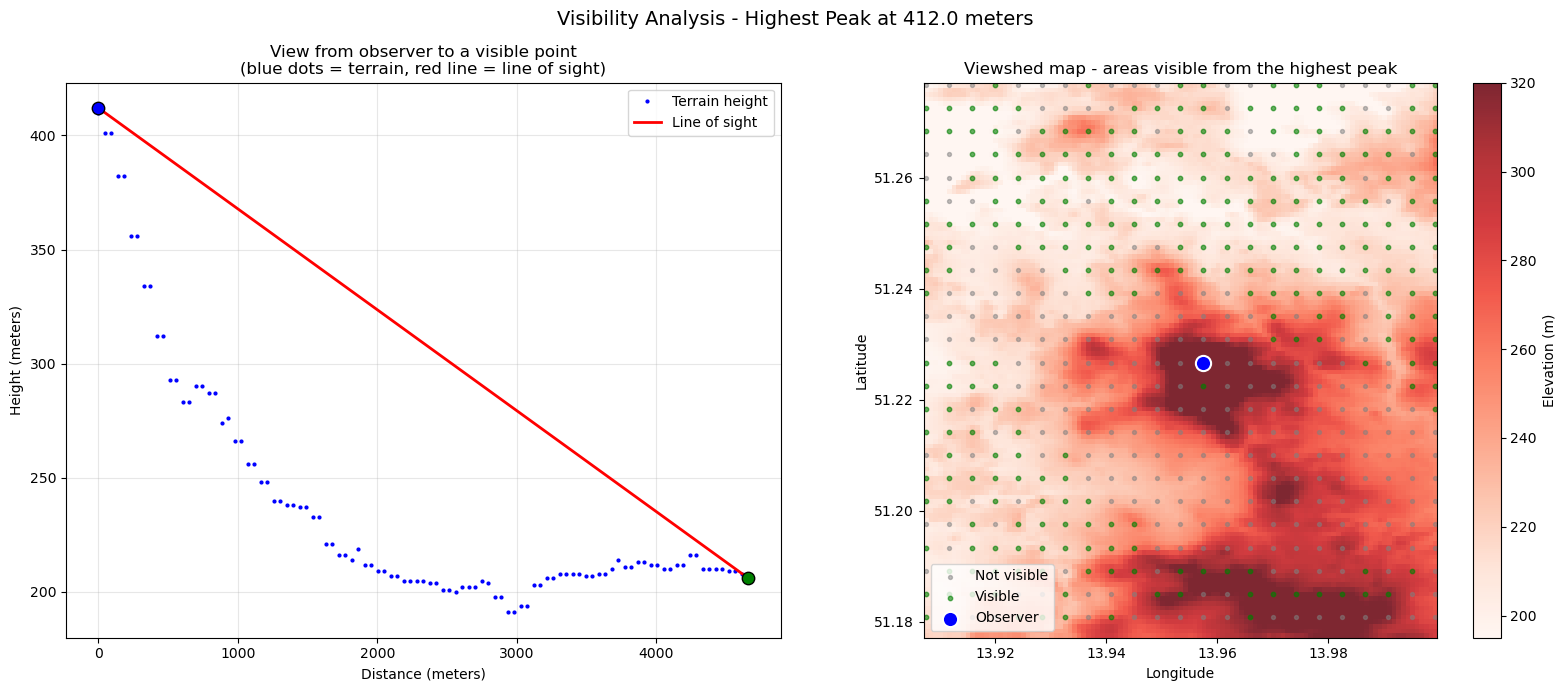

Done! Check I:\sichtbarkeitsanalyse\viewshed_result_5.png


In [1]:
"""
This code analyzes which areas are visible from the highest mountain peak in a region.

It does this by:
1. Loading elevation data (like a 3D map of the terrain)
2. Finding the tallest mountain
3. Checking if other points can be seen from that peak
4. Drawing a map showing visible vs hidden areas
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt


# 1: LOAD THE ELEVATION DATA


# Open the elevation file (like a black and white image where white = high, black = low)
file_path = r"I:\sichtbarkeitsanalyse\SRTMGL3.tiff"

with rasterio.open(file_path) as elevation_file:
    # Read the elevation data into a grid (like a spreadsheet of heights)
    full_elevation_grid = elevation_file.read(1).astype(np.float32)
    # Get info about the map's coordinate system and boundaries
    map_transform = elevation_file.transform
    map_crs = elevation_file.crs
    map_bounds = elevation_file.bounds

# Calculate each pixel size (latitude/longitude)
pixel_width = abs(map_transform.a)
pixel_height = abs(map_transform.e)
METERS_PER_DEGREE = 111320  # How many meters in one degree (roughly)

# Print some basic info about our elevation data
print(f"Size of elevation grid: {full_elevation_grid.shape}")
print(f"Maximum elevation: {np.max(full_elevation_grid):.1f} meters")
print(f"Minimum elevation: {np.min(full_elevation_grid):.1f} meters")
print(f"Average elevation: {np.mean(full_elevation_grid):.12f} meters")

# 2: FIND THE OBSERVER LOCATION


# Find where the highest elevation is in the grid
observer_row, observer_col = np.unravel_index(
    np.argmax(full_elevation_grid), 
    full_elevation_grid.shape
)

# Observer stands 2 meters above the ground (like a person's eye level)
observer_height = full_elevation_grid[observer_row, observer_col] + 2

# Convert grid position to real-world coordinates (longitude, latitude)
with rasterio.open(file_path) as elevation_file:
    observer_lon, observer_lat = elevation_file.xy(observer_row, observer_col)

print(f"\nHighest point is at: ({observer_lon:.6f}, {observer_lat:.6f})")
print(f"Observer height: {observer_height:.1f} meters")


# 3: CROP THE MAP TO A SMALLER AREA AROUND THE PEAK

# We only care about areas within 5 km 
clip_size = 0.05 ##0.05 is in degrees

# Calculate which pixels to keep (like cropping a photo)
row_start = max(0, int((map_bounds.top - (observer_lat + clip_size)) / pixel_height))
row_end = min(full_elevation_grid.shape[0], int((map_bounds.top - (observer_lat - clip_size)) / pixel_height))
col_start = max(0, int((observer_lon - clip_size - map_bounds.left) / pixel_width))
col_end = min(full_elevation_grid.shape[1], int((observer_lon + clip_size - map_bounds.left) / pixel_width))

# cropped elevation
elevation_grid = full_elevation_grid[row_start:row_end, col_start:col_end]

# Update observer position for the cropped grid
observer_row_cropped = observer_row - row_start
observer_col_cropped = observer_col - col_start


#4: HELPER FUNCTIONS FOR VISIBILITY ANALYSIS


def pixel_to_coordinates(row, col):
    """Convert pixel position (row, column) to real-world coordinates (lon, lat)"""
    lon = map_bounds.left + (col_start + col + 0.5) * pixel_width
    lat = map_bounds.top - (row_start + row + 0.5) * pixel_height
    return lon, lat

def can_see_point(elevation_grid, from_row, from_col, to_row, to_col, observer_height):
    """
    Check if a point is visible from the observer.
    
    This works by drawing a straight line from observer to target and checking
    if any terrain blocks the view.
    """
    from_height = observer_height
    to_height = elevation_grid[to_row, to_col]
    
    # Calculate how many steps we need to check along the line
    row_diff = to_row - from_row
    col_diff = to_col - from_col
    steps = int(np.hypot(row_diff, col_diff))
    
    # If it's the same point, it's visible
    if steps == 0:
        return True
    
    # Check each point along the line
    for step in range(1, steps):
        fraction = step / steps
        check_row = int(from_row + row_diff * fraction)
        check_col = int(from_col + col_diff * fraction)
        
        # Height of the terrain at this point
        terrain_height = elevation_grid[check_row, check_col]
        
        # Height of the line-of-sight at this point
        los_height = from_height + (to_height - from_height) * fraction
        
        # If terrain blocks the view, point is not visible
        if terrain_height > los_height:
            return False
    
    return True

def get_line_profile(elevation_grid, from_row, from_col, to_row, to_col, observer_height):
    """
    Get elevation profile along a line between two points.
    Used for drawing the cross-section view.
    """
    from_height = observer_height
    to_height = elevation_grid[to_row, to_col]
    
    row_diff = to_row - from_row
    col_diff = to_col - from_col
    steps = int(np.hypot(row_diff, col_diff)) * 2
    
    # Calculate total distance in meters
    total_distance = np.sqrt(
        (row_diff * pixel_height * METERS_PER_DEGREE) ** 2 +
        (col_diff * pixel_width * METERS_PER_DEGREE) ** 2
    )
    
    distances = []
    terrain_heights = []
    
    for step in range(steps + 1):
        fraction = step / steps
        r = max(0, min(int(from_row + row_diff * fraction), elevation_grid.shape[0]-1))
        c = max(0, min(int(from_col + col_diff * fraction), elevation_grid.shape[1]-1))
        distances.append(fraction * total_distance)
        terrain_heights.append(elevation_grid[r, c])
    
    # Line-of-sight heights
    los_heights = from_height + (to_height - from_height) * np.linspace(0, 1, steps + 1)
    
    return np.array(distances), np.array(terrain_heights), los_heights


#5: CALCULATE VIEWSHED (WHICH POINTS ARE VISIBLE)


# We'll check every 5th pixel to save time
check_every_n_pixels = 5
rows, cols = elevation_grid.shape

visible_points = []
hidden_points = []

print("\nCalculating which points are visible...")
for r in range(0, rows, check_every_n_pixels):
    for c in range(0, cols, check_every_n_pixels):
        # Skip points too close to the observer
        if abs(r - observer_row_cropped) < 5 and abs(c - observer_col_cropped) < 5:
            continue
        
        if can_see_point(elevation_grid, observer_row_cropped, observer_col_cropped, r, c, observer_height):
            visible_points.append((r, c))
        else:
            hidden_points.append((r, c))

print(f"Visible points: {len(visible_points)}")
print(f"Hidden points: {len(hidden_points)}")

# Pick one visible and one hidden point for the cross-section view
visible_array = np.array(visible_points)
distances_from_observer = np.hypot(
    visible_array[:, 0] - observer_row_cropped, 
    visible_array[:, 1] - observer_col_cropped
)
mid_point_index = np.argsort(distances_from_observer)[len(distances_from_observer) // 2]
sample_visible = tuple(visible_array[mid_point_index])
sample_hidden = hidden_points[len(hidden_points) // 2]


#6: RESULTS


# Create a figure with two side-by-side plots
fig, (ax_profile, ax_map) = plt.subplots(1, 2, figsize=(16, 7))


# PLOT: Cross-section view (like slicing through the terrain)

distances, terrain, los = get_line_profile(
    elevation_grid, 
    observer_row_cropped, observer_col_cropped,
    sample_visible[0], sample_visible[1], 
    observer_height
)

ax_profile.plot(distances, terrain, 'b.', markersize=4, label='Terrain height')
ax_profile.plot(distances, los, 'r-', linewidth=2, label='Line of sight')
ax_profile.scatter(0, observer_height, c='blue', s=80, edgecolors='black', zorder=5)
ax_profile.scatter(distances[-1], terrain[-1], c='green', s=80, edgecolors='black', zorder=5)
ax_profile.set_title('View from observer to a visible point\n(blue dots = terrain, red line = line of sight)')
ax_profile.set_xlabel('Distance (meters)')
ax_profile.set_ylabel('Height (meters)')
ax_profile.legend()
ax_profile.grid(True, alpha=0.3)


# Show elevation as background
map_extent = [
    map_bounds.left + col_start * pixel_width,
    map_bounds.left + col_end * pixel_width,
    map_bounds.top - row_end * pixel_height,
    map_bounds.top - row_start * pixel_height
]

im = ax_map.imshow(
    elevation_grid, 
    cmap='Reds', 
    extent=map_extent, 
    origin='upper',
    alpha=0.85,
    vmin=np.percentile(elevation_grid, 5),
    vmax=np.percentile(elevation_grid, 95)
)
plt.colorbar(im, ax=ax_map, label='Elevation (m)')

# Convert pixel coordinates to real coordinates for plotting
def points_to_coordinates(points):
    lons = [pixel_to_coordinates(r, c)[0] for r, c in points]
    lats = [pixel_to_coordinates(r, c)[1] for r, c in points]
    return np.array(lons), np.array(lats)

# Plot visible and hidden points
hidden_lons, hidden_lats = points_to_coordinates(hidden_points)
visible_lons, visible_lats = points_to_coordinates(visible_points)

ax_map.scatter(hidden_lons, hidden_lats, c='gray', s=8, alpha=0.5, label='Not visible')
ax_map.scatter(visible_lons, visible_lats, c='green', s=10, alpha=0.6, label='Visible')
ax_map.scatter(observer_lon, observer_lat, c='blue', s=120, edgecolors='white', linewidths=1.5, label='Observer')

ax_map.set_title('Viewshed map - areas visible from the highest peak')
ax_map.set_xlabel('Longitude')
ax_map.set_ylabel('Latitude')
ax_map.legend(loc='lower left')
ax_map.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax_map.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

# Final touches
plt.suptitle(f'Visibility Analysis - Highest Peak at {observer_height:.1f} meters', fontsize=14)
plt.tight_layout()

# Save and show
plt.savefig(r"I:\sichtbarkeitsanalyse\viewshed_result_5.png", dpi=150, bbox_inches='tight')
plt.show()